# 0. Setup & Load Data

Notebook ini melakukan Exploratory Data Analysis (EDA) pada application_train.csv sebagai bagian dari Home Credit Default Risk project. Fokus EDA: memahami distribusi target, kualitas data (missing value), relevansi fitur terhadap risiko default (via Information Value), serta mendeteksi anomali data. Output utama notebook ini adalah daftar kandidat fitur yang akan diproses lebih lanjut (redundancy check via korelasi) di 03_feature_engineering.ipynb.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

df = pd.read_csv("../data/raw/application_train.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single /

# 1. Overview Dataset

Tujuan: memahami struktur data secara umum — tipe data per kolom, jumlah fitur numerik vs kategorikal — sebelum masuk ke analisis lebih dalam.

In [2]:
print(df.info())

dtype_summary = df.dtypes.value_counts()
print("\nJumlah kolom per tipe data:")
print(dtype_summary)

n_numeric = df.select_dtypes(include=[np.number]).shape[1]
n_categorical = df.select_dtypes(include="object").shape[1]
print(f"\nFitur numerik : {n_numeric}")
print(f"Fitur kategorikal: {n_categorical}")

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB
None

Jumlah kolom per tipe data:
float64    65
int64      41
str        16
Name: count, dtype: int64

Fitur numerik : 106
Fitur kategorikal: 16


C:\Users\USER\AppData\Local\Temp\ipykernel_21740\3674798514.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  n_categorical = df.select_dtypes(include="object").shape[1]


# 1.b Duplikasi & Konsistensi Nilai Dasar

In [3]:
n_duplicate_rows = df.duplicated().sum()
n_duplicate_ids = df["SK_ID_CURR"].duplicated().sum()

print(f"Jumlah baris duplikat (seluruh kolom identik): {n_duplicate_rows}")
print(f"Jumlah SK_ID_CURR duplikat: {n_duplicate_ids}")

Jumlah baris duplikat (seluruh kolom identik): 0
Jumlah SK_ID_CURR duplikat: 0


# 2. Distribusi & Imbalance Ratio TARGET

Tujuan: mengetahui seberapa timpang proporsi klien default (TARGET=1) vs tidak default (TARGET=0). Rasio yang sangat timpang berdampak pada pemilihan metrik evaluasi (accuracy tidak reliable) dan strategi handling imbalance (class_weight, SMOTE) di tahap modeling nanti.

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


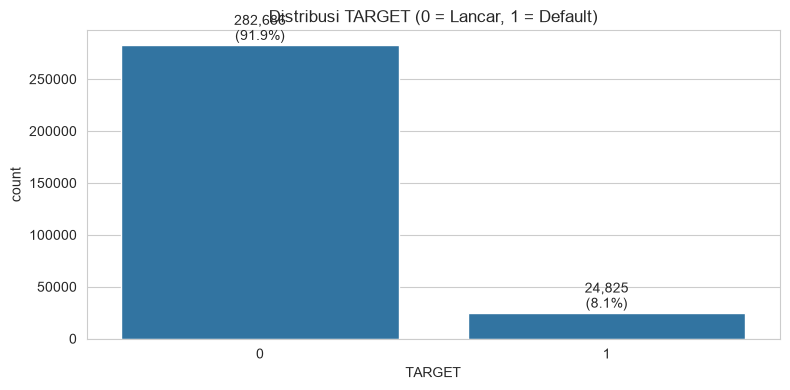

In [4]:
target_counts = df["TARGET"].value_counts()
target_pct = df["TARGET"].value_counts(normalize=True) * 100

print(target_counts)
print(target_pct.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(x="TARGET", data=df, ax=ax)
ax.set_title("Distribusi TARGET (0 = Lancar, 1 = Default)")
for i, v in enumerate(target_counts):
    ax.text(i, v + 5000, f"{v:,}\n({target_pct.iloc[i]:.1f}%)", ha="center")
plt.tight_layout()
plt.savefig("../reports/figures/01_target_distribution.png", dpi=150)
plt.show()

# 3. Missing Value Overview

Tujuan: mengidentifikasi kolom dengan proporsi missing value tinggi. Ini jadi salah satu input untuk kriteria seleksi fitur di Bagian 5, dan juga jadi dasar strategi imputasi di tahap Data Cleaning.

In [5]:
feature_cols = [c for c in df.columns if c not in ["SK_ID_CURR", "TARGET"]]

missing_count = df[feature_cols].isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

n_with_missing = (missing_df["missing_count"] > 0).sum()
print(f"Jumlah kolom dengan missing value: {n_with_missing} dari {len(feature_cols)} fitur")
missing_df[missing_df["missing_count"] > 0].head(20)

Jumlah kolom dengan missing value: 67 dari 120 fitur


,missing_count,missing_pct
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


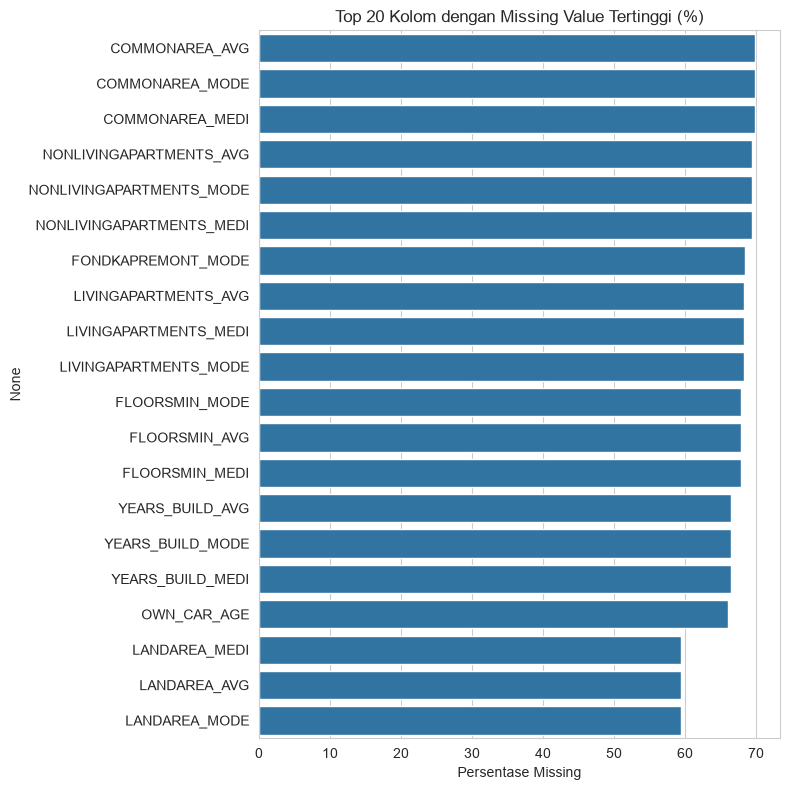

In [6]:
top20_missing = missing_df[missing_df["missing_count"] > 0].head(20)

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=top20_missing["missing_pct"], y=top20_missing.index, ax=ax)
ax.set_title("Top 20 Kolom dengan Missing Value Tertinggi (%)")
ax.set_xlabel("Persentase Missing")
plt.tight_layout()
plt.savefig("../reports/figures/02_missing_values.png", dpi=150)
plt.show()

# 3.b Hidden Missing Value pada Kolom Kategorikal

In [7]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
placeholder_values = ["XNA", "Unknown", "XAP", "Not specified", "Other"]

hidden_missing_report = []
for col in categorical_cols:
    value_counts = df[col].value_counts(dropna=False)
    for placeholder in placeholder_values:
        if placeholder in value_counts.index:
            count = value_counts[placeholder]
            pct = count / len(df) * 100
            hidden_missing_report.append({
                "feature": col,
                "placeholder_value": placeholder,
                "count": count,
                "pct_of_data": round(pct, 2)
            })

hidden_missing_df = pd.DataFrame(hidden_missing_report).sort_values("pct_of_data", ascending=False)
print(f"Ditemukan {len(hidden_missing_df)} kombinasi kolom-placeholder yang berpotensi missing tersembunyi:")
hidden_missing_df

Ditemukan 4 kombinasi kolom-placeholder yang berpotensi missing tersembunyi:


C:\Users\USER\AppData\Local\Temp\ipykernel_21740\265831493.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


,feature,placeholder_value,count,pct_of_data
2,ORGANIZATION_TYPE,XNA,55374,18.01
3,ORGANIZATION_TYPE,Other,16683,5.43
1,NAME_FAMILY_STATUS,Unknown,2,0.00
0,CODE_GENDER,XNA,4,0.00


In [8]:
print("Perbandingan missing_pct (isnull) vs missing tersembunyi vs TRUE missing:\n")
for _, row in hidden_missing_df.iterrows():
    col = row["feature"]
    isnull_pct = missing_pct.get(col, 0.0)
    hidden_pct = row["pct_of_data"]
    true_missing_pct = isnull_pct + hidden_pct
    print(f"{col:25s} | isnull(): {isnull_pct:6.2f}% | '{row['placeholder_value']}': {hidden_pct:6.2f}% | TRUE: {true_missing_pct:6.2f}%")

Perbandingan missing_pct (isnull) vs missing tersembunyi vs TRUE missing:

ORGANIZATION_TYPE         | isnull():   0.00% | 'XNA':  18.01% | TRUE:  18.01%
ORGANIZATION_TYPE         | isnull():   0.00% | 'Other':   5.43% | TRUE:   5.43%
NAME_FAMILY_STATUS        | isnull():   0.00% | 'Unknown':   0.00% | TRUE:   0.00%
CODE_GENDER               | isnull():   0.00% | 'XNA':   0.00% | TRUE:   0.00%


# 3.c Pola Missingness Antar Kolom

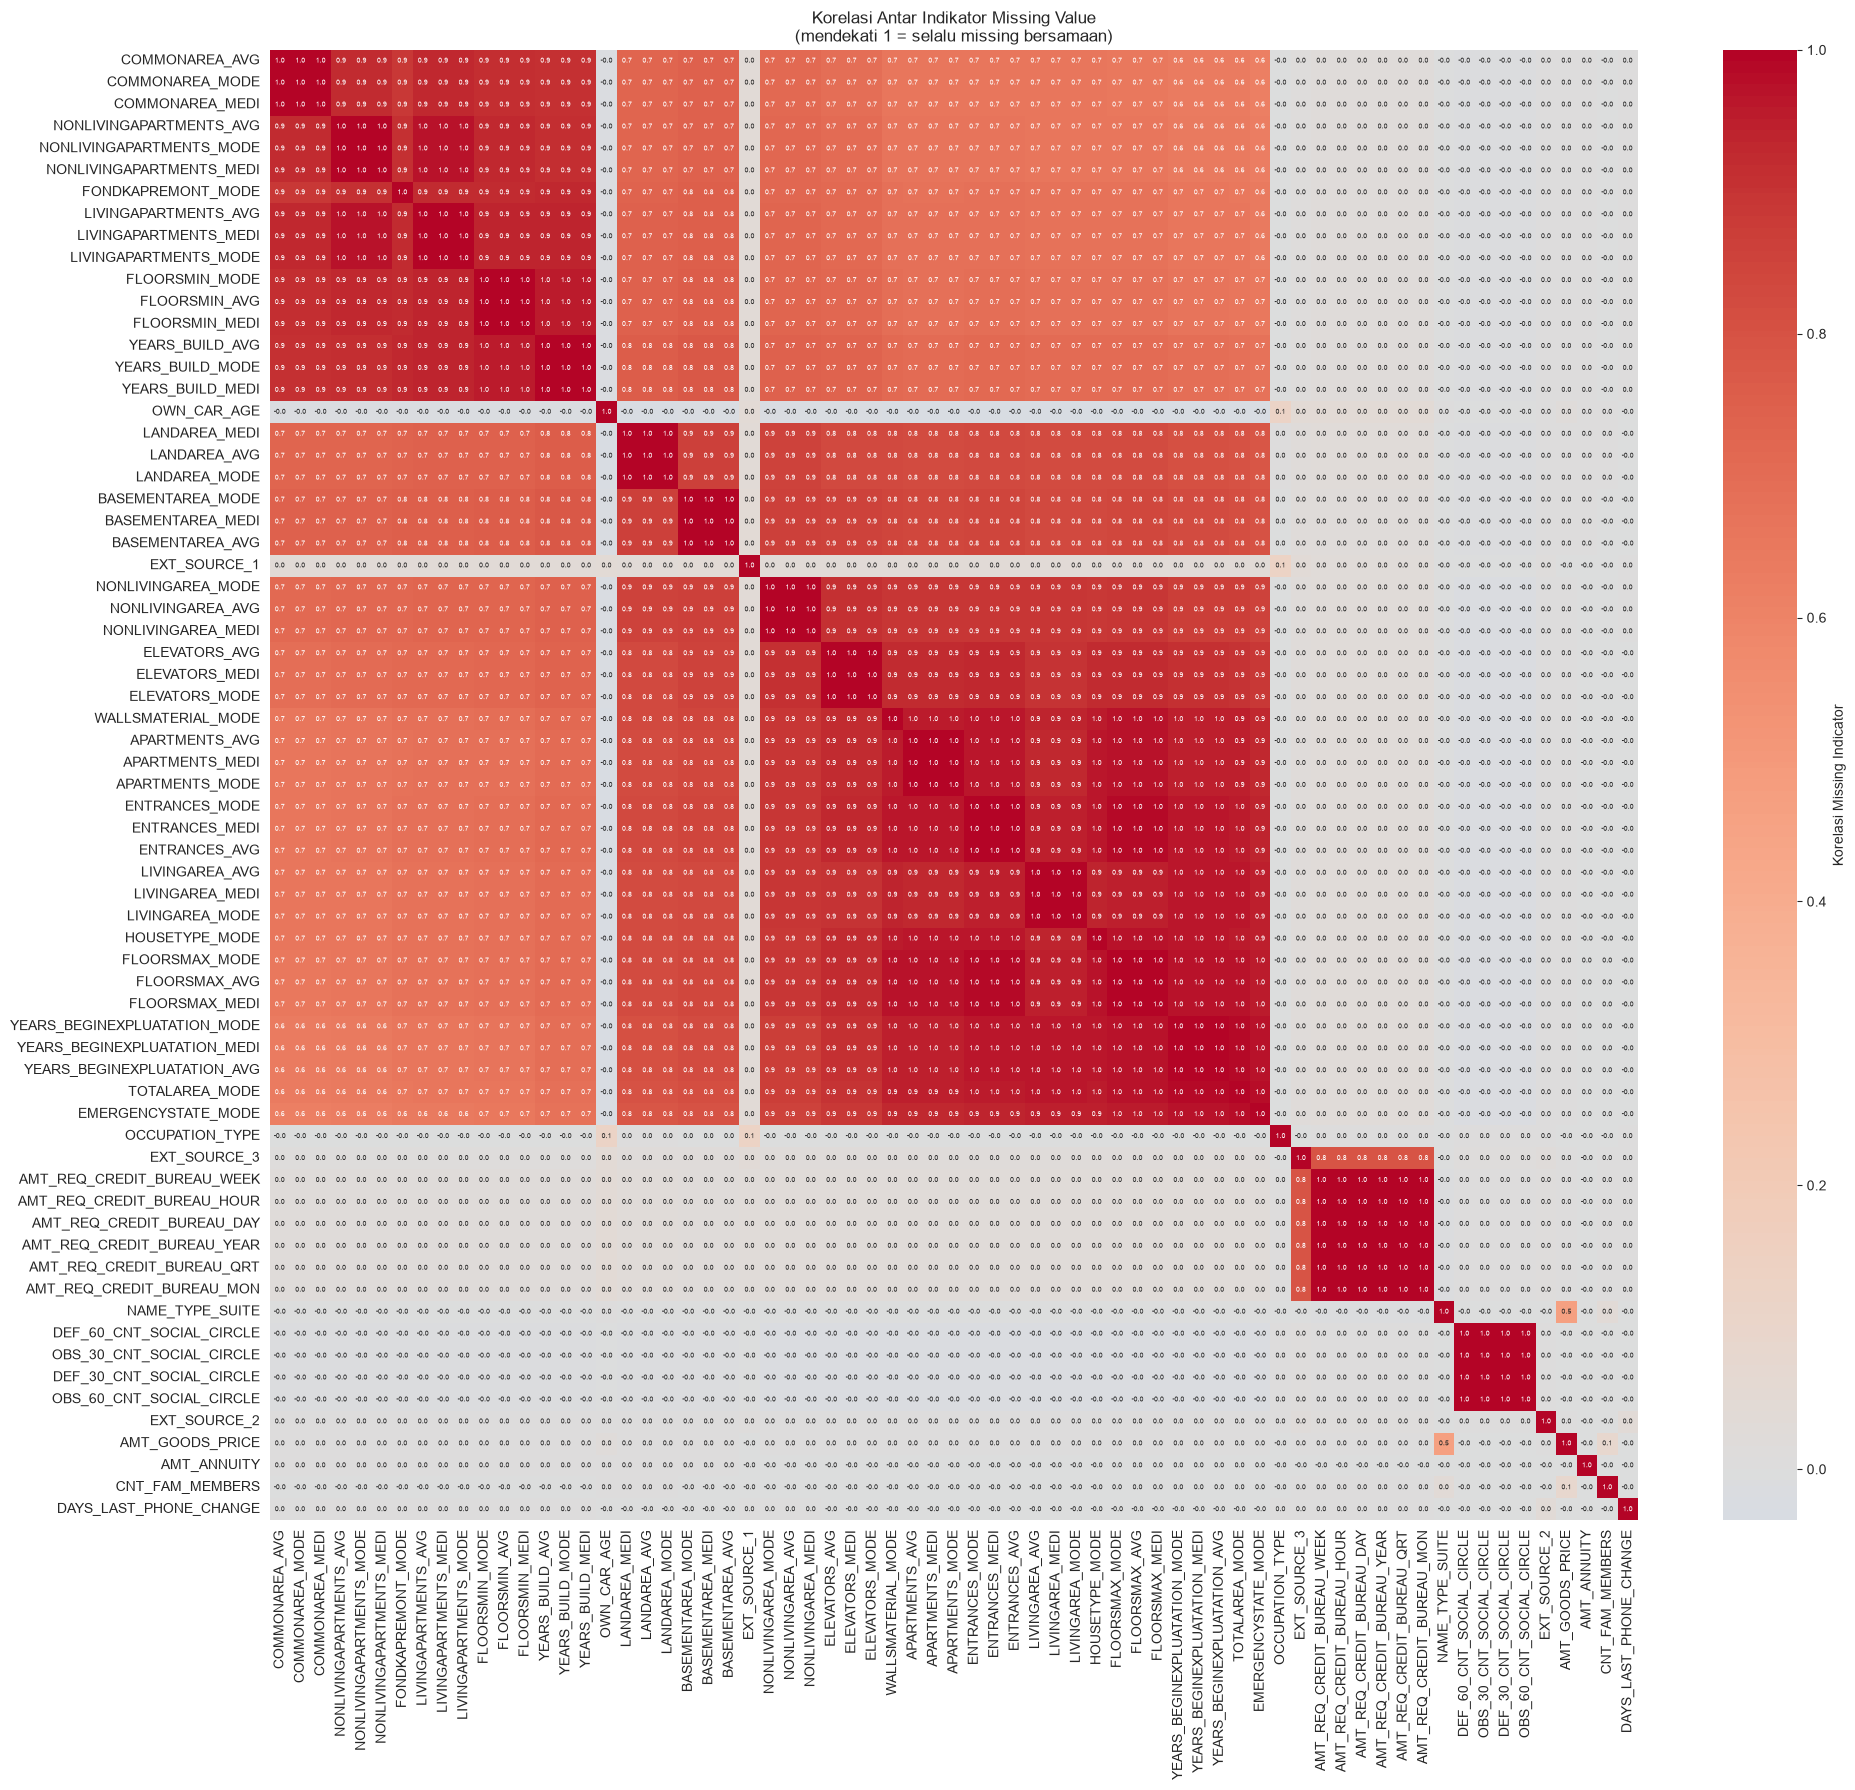

In [9]:
missing_cols = missing_df[missing_df["missing_count"] > 0].index.tolist()
missing_indicator = df[missing_cols].isnull().astype(int)
missing_corr = missing_indicator.corr()

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(missing_corr, cmap="coolwarm", center=0, ax=ax,
            annot=True, fmt=".1f", annot_kws={"size": 5},
            cbar_kws={"label": "Korelasi Missing Indicator"})
ax.set_title("Korelasi Antar Indikator Missing Value\n(mendekati 1 = selalu missing bersamaan)")
plt.tight_layout()
plt.savefig("../reports/figures/09_missing_correlation.png", dpi=150)
plt.show()

In [10]:
high_corr_pairs = []
for i in range(len(missing_corr.columns)):
    for j in range(i + 1, len(missing_corr.columns)):
        corr_val = missing_corr.iloc[i, j]
        if corr_val > 0.8:
            high_corr_pairs.append({
                "feature_1": missing_corr.columns[i],
                "feature_2": missing_corr.columns[j],
                "missing_correlation": round(corr_val, 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("missing_correlation", ascending=False)
print(f"Ditemukan {len(high_corr_df)} pasangan kolom dengan pola missing sangat mirip (corr > 0.8):")
high_corr_df.head(20)

Ditemukan 597 pasangan kolom dengan pola missing sangat mirip (corr > 0.8):


,feature_1,feature_2,missing_correlation
596,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,1.0
0,COMMONAREA_AVG,COMMONAREA_MODE,1.0
1,COMMONAREA_AVG,COMMONAREA_MEDI,1.0
595,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,1.0
579,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_QRT,1.0
578,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_YEAR,1.0
577,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_DAY,1.0
576,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_HOUR,1.0
566,YEARS_BEGINEXPLUATATION_MODE,YEARS_BEGINEXPLUATATION_MEDI,1.0
570,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,1.0


In [11]:
housing_related = [c for c in missing_cols if any(
    kw in c for kw in ["APARTMENT", "BASEMENT", "YEARS_BUILD", "COMMONAREA",
                        "ELEVATOR", "ENTRANCE", "FLOORSMAX", "FLOORSMIN",
                        "LANDAREA", "LIVINGAREA", "NONLIVING", "TOTALAREA"]
)]
avg_corr_within_group = missing_corr.loc[housing_related, housing_related].values.mean()
print(f"Rata-rata korelasi missing di antara {len(housing_related)} kolom housing: {avg_corr_within_group:.3f}")
print("Jika mendekati 1, ini konfirmasi missing-nya terstruktur per grup, bukan acak per kolom.")

Rata-rata korelasi missing di antara 40 kolom housing: 0.815
Jika mendekati 1, ini konfirmasi missing-nya terstruktur per grup, bukan acak per kolom.


# 4. Information Value (IV) — Relevansi Fitur terhadap TARGET

Tujuan: IV mengukur seberapa kuat sebuah fitur (numerik maupun kategorikal) membedakan klien default vs tidak default, berdasarkan Weight of Evidence (WoE) per bin. Missing value diperlakukan sebagai bin tersendiri karena missingness itu sendiri kadang informatif (bukan sekadar noise).

Standar kategori IV yang dipakai (umum di industri credit scoring):

IV < 0.02 → Useless

0.02–0.1 → Weak

0.1–0.3 → Medium

0.3–0.5 → Strong

> 0.5 → Suspicious (indikasi potensi data leakage, perlu dicek manual)

In [12]:
def calculate_iv(series, target, bins=10, epsilon=1e-6):
    """
    Hitung Information Value (IV) untuk satu fitur terhadap target biner.
    Fitur numerik dibagi ke `bins` kuantil; fitur kategorikal memakai kategori aslinya.
    Missing value diperlakukan sebagai bin tersendiri ("Missing").
    """
    df_temp = pd.DataFrame({"feature": series.values, "target": target.values})
    missing_mask = df_temp["feature"].isna()
    parts = []

    non_missing = df_temp[~missing_mask].copy()
    if len(non_missing) > 0:
        if pd.api.types.is_numeric_dtype(non_missing["feature"]):
            try:
                non_missing["bin"] = pd.qcut(non_missing["feature"], q=bins, duplicates="drop")
            except ValueError:
                non_missing["bin"] = non_missing["feature"]
        else:
            non_missing["bin"] = non_missing["feature"].astype(str)
        parts.append(non_missing[["bin", "target"]])

    if missing_mask.sum() > 0:
        missing_part = df_temp[missing_mask].copy()
        missing_part["bin"] = "Missing"
        parts.append(missing_part[["bin", "target"]])

    if not parts:
        return np.nan

    combined = pd.concat(parts, ignore_index=True)
    grouped = combined.groupby("bin", observed=True)["target"].agg(["count", "sum"])
    grouped.columns = ["total", "bad"]
    grouped["good"] = grouped["total"] - grouped["bad"]

    total_bad = grouped["bad"].sum()
    total_good = grouped["good"].sum()

    grouped["dist_bad"] = (grouped["bad"] + epsilon) / (total_bad + epsilon)
    grouped["dist_good"] = (grouped["good"] + epsilon) / (total_good + epsilon)
    grouped["woe"] = np.log(grouped["dist_good"] / grouped["dist_bad"])
    grouped["iv_component"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["woe"]

    return grouped["iv_component"].sum()


def categorize_iv(iv):
    if iv < 0.02:
        return "Useless"
    elif iv < 0.1:
        return "Weak"
    elif iv < 0.3:
        return "Medium"
    elif iv < 0.5:
        return "Strong"
    else:
        return "Suspicious"

In [13]:
numeric_cols_for_iv = df.select_dtypes(include=[np.number]).drop(columns=["SK_ID_CURR", "TARGET"]).columns.tolist()
categorical_cols_for_iv = df.select_dtypes(include="object").columns.tolist()
all_cols_for_iv = numeric_cols_for_iv + categorical_cols_for_iv

iv_results = {col: calculate_iv(df[col], df["TARGET"], bins=10) for col in all_cols_for_iv}

iv_df_all = pd.DataFrame({"information_value": pd.Series(iv_results)})
iv_df_all["dtype"] = ["numeric" if c in numeric_cols_for_iv else "categorical" for c in iv_df_all.index]
iv_df_all["category"] = iv_df_all["information_value"].apply(categorize_iv)
iv_df_all = iv_df_all.sort_values("information_value", ascending=False)

print(f"Total fitur dianalisis: {len(iv_df_all)}")
iv_df_all.head(15)

C:\Users\USER\AppData\Local\Temp\ipykernel_21740\2460090600.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_for_iv = df.select_dtypes(include="object").columns.tolist()


Total fitur dianalisis: 120


,information_value,dtype,category
EXT_SOURCE_3,0.329443,numeric,Strong
EXT_SOURCE_2,0.306473,numeric,Strong
EXT_SOURCE_1,0.150934,numeric,Medium
DAYS_EMPLOYED,0.101263,numeric,Medium
AMT_GOODS_PRICE,0.091941,numeric,Weak
DAYS_BIRTH,0.084200,numeric,Weak
OCCUPATION_TYPE,0.082865,categorical,Weak
ORGANIZATION_TYPE,0.073368,categorical,Weak
NAME_INCOME_TYPE,0.059715,categorical,Weak
NAME_EDUCATION_TYPE,0.050836,categorical,Weak


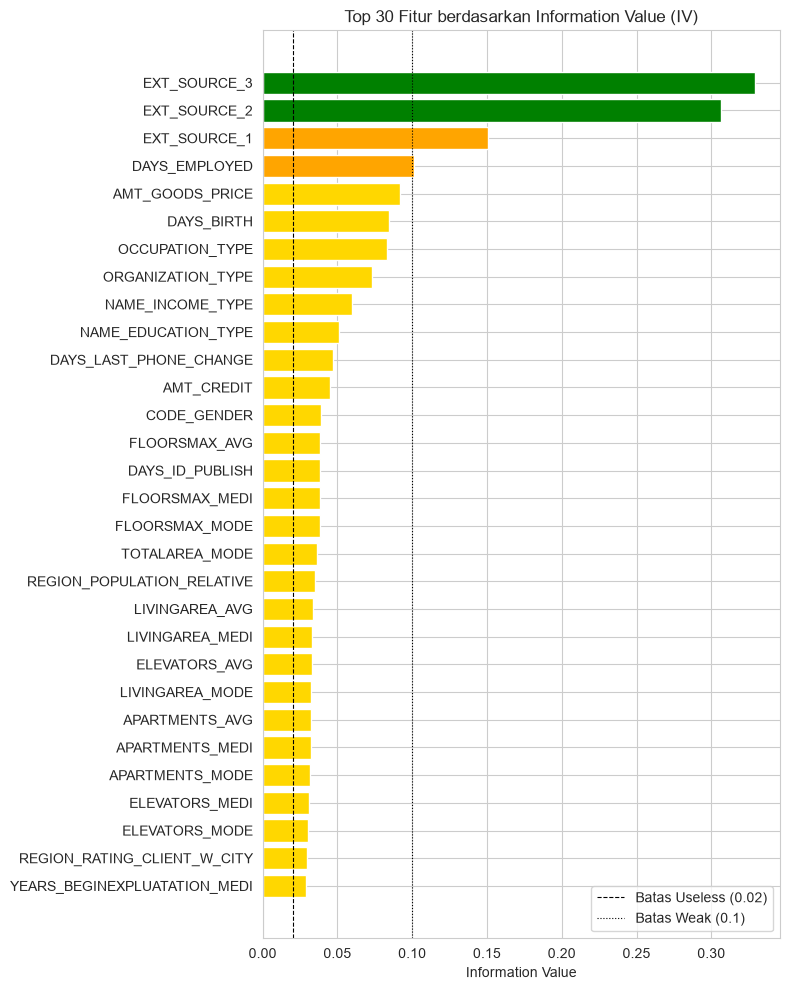

In [14]:
top30_iv = iv_df_all.dropna().head(30)
category_colors = {"Suspicious": "darkred", "Strong": "green", "Medium": "orange", "Weak": "gold", "Useless": "gray"}
colors = top30_iv["category"].map(category_colors)

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(top30_iv.index, top30_iv["information_value"], color=colors)
ax.axvline(0.02, color="black", linestyle="--", linewidth=0.8, label="Batas Useless (0.02)")
ax.axvline(0.1, color="black", linestyle=":", linewidth=0.8, label="Batas Weak (0.1)")
ax.invert_yaxis()
ax.set_xlabel("Information Value")
ax.set_title("Top 30 Fitur berdasarkan Information Value (IV)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/03_iv_ranking.png", dpi=150)
plt.show()

# 5. Seleksi Kandidat Fitur: Top 10 IV OR Missing < 51%
Tujuan: menentukan daftar kandidat fitur yang akan diproses lebih lanjut di 03_feature_engineering.ipynb. Aturan seleksi (OR, bukan AND):

Fitur masuk jika berada di Top 10 IV, berapapun persentase missing-nya.

Fitur masuk jika missing < 51%, berapapun nilai IV-nya.

Fitur dibuang hanya jika IV-nya rendah dan missing-nya ≥ 51% sekaligus.

Catatan penting: karena mayoritas fitur di dataset ini punya missing < 51%, hasil seleksi ini akan menyisakan fitur dalam jumlah besar (bukan cuma puluhan) — ini disengaja. Tahap ini hanya bertugas membuang fitur yang jelas tidak berguna (IV kecil + data nyaris kosong). Pemangkasan lebih lanjut karena redundansi antar fitur (korelasi tinggi, duplikat konsep) dilakukan di tahap Feature Engineering, bukan di sini.

In [15]:
TOP_N_IV = 10
MISSING_THRESHOLD = 51.0

missing_pct_all = missing_pct.reindex(iv_df_all.index)

top_iv_features = iv_df_all.sort_values("information_value", ascending=False).head(TOP_N_IV).index
low_missing_features = missing_pct_all[missing_pct_all < MISSING_THRESHOLD].index

selected_features = sorted(set(top_iv_features) | set(low_missing_features))

reasons = []
for col in selected_features:
    in_top_iv = col in top_iv_features
    in_low_missing = col in low_missing_features
    if in_top_iv and in_low_missing:
        reasons.append("Top10_IV & Missing<51%")
    elif in_top_iv:
        reasons.append("Top10_IV only (missing>=51%)")
    else:
        reasons.append("Missing<51% only (IV rendah)")

selected_df = pd.DataFrame({
    "feature": selected_features,
    "information_value": iv_df_all.loc[selected_features, "information_value"].round(6).values,
    "missing_pct": missing_pct_all.loc[selected_features].round(2).values,
    "dtype": iv_df_all.loc[selected_features, "dtype"].values,
    "iv_category": iv_df_all.loc[selected_features, "category"].values,
    "reason": reasons
}).sort_values("information_value", ascending=False).reset_index(drop=True)

excluded_features = sorted(set(iv_df_all.index) - set(selected_features))

print(f"Total fitur dianalisis      : {len(iv_df_all)}")
print(f"Fitur TERPILIH (kandidat FE) : {len(selected_df)}")
print(f"Fitur DIBUANG (IV rendah & missing>=51%): {len(excluded_features)}")
print("\nContoh fitur yang dibuang:")
print(excluded_features[:15])

selected_df.head(20)

Total fitur dianalisis      : 120
Fitur TERPILIH (kandidat FE) : 91
Fitur DIBUANG (IV rendah & missing>=51%): 29

Contoh fitur yang dibuang:
['BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE', 'COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE', 'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE', 'FONDKAPREMONT_MODE', 'LANDAREA_AVG', 'LANDAREA_MEDI']


,feature,information_value,missing_pct,dtype,iv_category,reason
0,EXT_SOURCE_3,0.329443,19.83,numeric,Strong,Top10_IV & Missing<51%
1,EXT_SOURCE_2,0.306473,0.21,numeric,Strong,Top10_IV & Missing<51%
2,EXT_SOURCE_1,0.150934,56.38,numeric,Medium,Top10_IV only (missing>=51%)
3,DAYS_EMPLOYED,0.101263,0.00,numeric,Medium,Top10_IV & Missing<51%
4,AMT_GOODS_PRICE,0.091941,0.09,numeric,Weak,Top10_IV & Missing<51%
5,DAYS_BIRTH,0.084200,0.00,numeric,Weak,Top10_IV & Missing<51%
6,OCCUPATION_TYPE,0.082865,31.35,categorical,Weak,Top10_IV & Missing<51%
7,ORGANIZATION_TYPE,0.073368,0.00,categorical,Weak,Top10_IV & Missing<51%
8,NAME_INCOME_TYPE,0.059715,0.00,categorical,Weak,Top10_IV & Missing<51%
9,NAME_EDUCATION_TYPE,0.050836,0.00,categorical,Weak,Top10_IV & Missing<51%


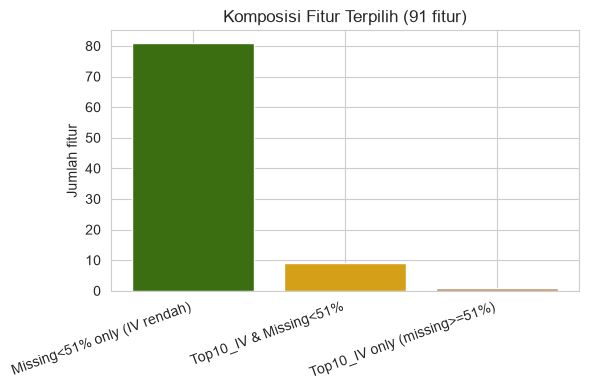

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
reason_counts = selected_df["reason"].value_counts()
ax.bar(reason_counts.index, reason_counts.values, color=["#3B6D11", "#D4A017", "#C4956A"])
ax.set_title(f"Komposisi Fitur Terpilih ({len(selected_df)} fitur)")
ax.set_ylabel("Jumlah fitur")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/04_selection_composition.png", dpi=150)
plt.show()

In [17]:
os.makedirs("../data/processed", exist_ok=True)
selected_df.to_csv("../data/processed/selected_features_eda.csv", index=False)
print("Tersimpan: ../data/processed/selected_features_eda.csv")
print(f"Jumlah fitur untuk tahap Feature Engineering: {len(selected_df)}")

Tersimpan: ../data/processed/selected_features_eda.csv
Jumlah fitur untuk tahap Feature Engineering: 91


In [18]:
affected_in_selection = hidden_missing_df[hidden_missing_df["feature"].isin(selected_df["feature"])]
print("Fitur TERPILIH di Bagian 5 yang ternyata punya hidden missing value:")
print(affected_in_selection[["feature", "placeholder_value", "pct_of_data"]])

print("\nCatatan: fitur di atas tetap masuk kandidat FE karena true missing masih < 51%.")
print("Placeholder ini akan diganti menjadi NaN secara eksplisit di 02_Cleaning.ipynb,")
print("agar strategi imputasi/encoding konsisten dengan kolom missing lainnya.")

Fitur TERPILIH di Bagian 5 yang ternyata punya hidden missing value:
              feature placeholder_value  pct_of_data
2   ORGANIZATION_TYPE               XNA        18.01
3   ORGANIZATION_TYPE             Other         5.43
1  NAME_FAMILY_STATUS           Unknown         0.00
0         CODE_GENDER               XNA         0.00

Catatan: fitur di atas tetap masuk kandidat FE karena true missing masih < 51%.
Placeholder ini akan diganti menjadi NaN secara eksplisit di 02_Cleaning.ipynb,
agar strategi imputasi/encoding konsisten dengan kolom missing lainnya.


# 5.b Near-Zero Variance Check (mencari kolom yang memiliki kemiripan data 99%)

In [37]:
NZV_THRESHOLD = 0.99

nzv_report = []
for col in selected_df["feature"]:
    if col not in df.columns:
        continue
    value_counts_norm = df[col].value_counts(normalize=True, dropna=False)
    top_freq = value_counts_norm.iloc[0]
    if top_freq >= NZV_THRESHOLD:
        nzv_report.append({
            "feature": col,
            "dominant_value": value_counts_norm.index[0],
            "dominant_pct": round(top_freq * 100, 2),
            "n_unique": df[col].nunique(dropna=False)
        })

nzv_df = pd.DataFrame(nzv_report).sort_values("dominant_pct", ascending=False)
print(f"Fitur near-constant (>{NZV_THRESHOLD*100:.0f}% nilai sama) dari {len(selected_df)} fitur terpilih:")
nzv_df

Fitur near-constant (>99% nilai sama) dari 91 fitur terpilih:


,feature,dominant_value,dominant_pct,n_unique
0,FLAG_MOBIL,1,100.00,2
9,FLAG_DOCUMENT_12,0,100.00,2
17,FLAG_DOCUMENT_10,0,100.00,2
6,FLAG_DOCUMENT_2,0,100.00,2
3,FLAG_DOCUMENT_4,0,99.99,2
1,FLAG_DOCUMENT_7,0,99.98,2
12,FLAG_DOCUMENT_17,0,99.97,2
4,FLAG_DOCUMENT_21,0,99.97,2
7,FLAG_DOCUMENT_20,0,99.95,2
5,FLAG_DOCUMENT_19,0,99.94,2


In [20]:
selected_df["is_near_zero_variance"] = selected_df["feature"].isin(nzv_df["feature"])
print(f"Total fitur near-zero variance dalam daftar kandidat: {selected_df['is_near_zero_variance'].sum()}")
print("Catatan: fitur ini tetap dibawa ke 03_feature_engineering.ipynb sebagai kandidat,")
print("tapi akan dievaluasi via VarianceThreshold di sana — dipertahankan hanya jika IV-nya tinggi.")

selected_df.to_csv("../data/processed/selected_features_eda.csv", index=False)
print("selected_features_eda.csv diperbarui dengan kolom 'is_near_zero_variance'.")

Total fitur near-zero variance dalam daftar kandidat: 18
Catatan: fitur ini tetap dibawa ke 03_feature_engineering.ipynb sebagai kandidat,
tapi akan dievaluasi via VarianceThreshold di sana — dipertahankan hanya jika IV-nya tinggi.
selected_features_eda.csv diperbarui dengan kolom 'is_near_zero_variance'.


# 6. EDA Umum — Insight Bisnis Paling Utama Dalam Credit & Deteksi Anomali
Bagian ini terpisah dari proses seleksi fitur di atas. Tujuannya untuk memahami distribusi fitur kunci, mendeteksi anomali (khususnya DAYS_EMPLOYED yang punya sentinel value 365243 hari ≈ 1000 tahun), dan menghasilkan insight yang bisa dikomunikasikan ke stakeholder non-teknis.

In [21]:
# --- NUMERIK ---
numeric_key_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
                     "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
                     "DAYS_EMPLOYED", "AMT_GOODS_PRICE", "DAYS_BIRTH"]

print(df[numeric_key_cols].describe())

missing = df[numeric_key_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print("\n--- Missing value per kolom ---")
print(pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}))

anomaly_count = (df["DAYS_EMPLOYED"] == 365243).sum()
print(f"\nDAYS_EMPLOYED anomaly (365243): {anomaly_count} ({anomaly_count/len(df)*100:.2f}%)")

q1, q3 = df["AMT_INCOME_TOTAL"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
income_outliers = (df["AMT_INCOME_TOTAL"] > upper).sum()
print(f"AMT_INCOME_TOTAL di atas batas IQR ({upper:,.0f}): {income_outliers} ({income_outliers/len(df)*100:.2f}%)")

age_years = -df["DAYS_BIRTH"] / 365.25
print(f"Rentang umur (dari DAYS_BIRTH): {age_years.min():.1f} - {age_years.max():.1f} tahun")


       AMT_INCOME_TOTAL    AMT_CREDIT    AMT_ANNUITY   EXT_SOURCE_1  \
count      3.075110e+05  3.075110e+05  307499.000000  134133.000000   
mean       1.687979e+05  5.990260e+05   27108.573909       0.502130   
std        2.371231e+05  4.024908e+05   14493.737315       0.211062   
min        2.565000e+04  4.500000e+04    1615.500000       0.014568   
25%        1.125000e+05  2.700000e+05   16524.000000       0.334007   
50%        1.471500e+05  5.135310e+05   24903.000000       0.505998   
75%        2.025000e+05  8.086500e+05   34596.000000       0.675053   
max        1.170000e+08  4.050000e+06  258025.500000       0.962693   

       EXT_SOURCE_2   EXT_SOURCE_3  DAYS_EMPLOYED  AMT_GOODS_PRICE  \
count  3.068510e+05  246546.000000  307511.000000     3.072330e+05   
mean   5.143927e-01       0.510853   63815.045904     5.383962e+05   
std    1.910602e-01       0.194844  141275.766519     3.694465e+05   
min    8.170000e-08       0.000527  -17912.000000     4.050000e+04   
25%    3.9

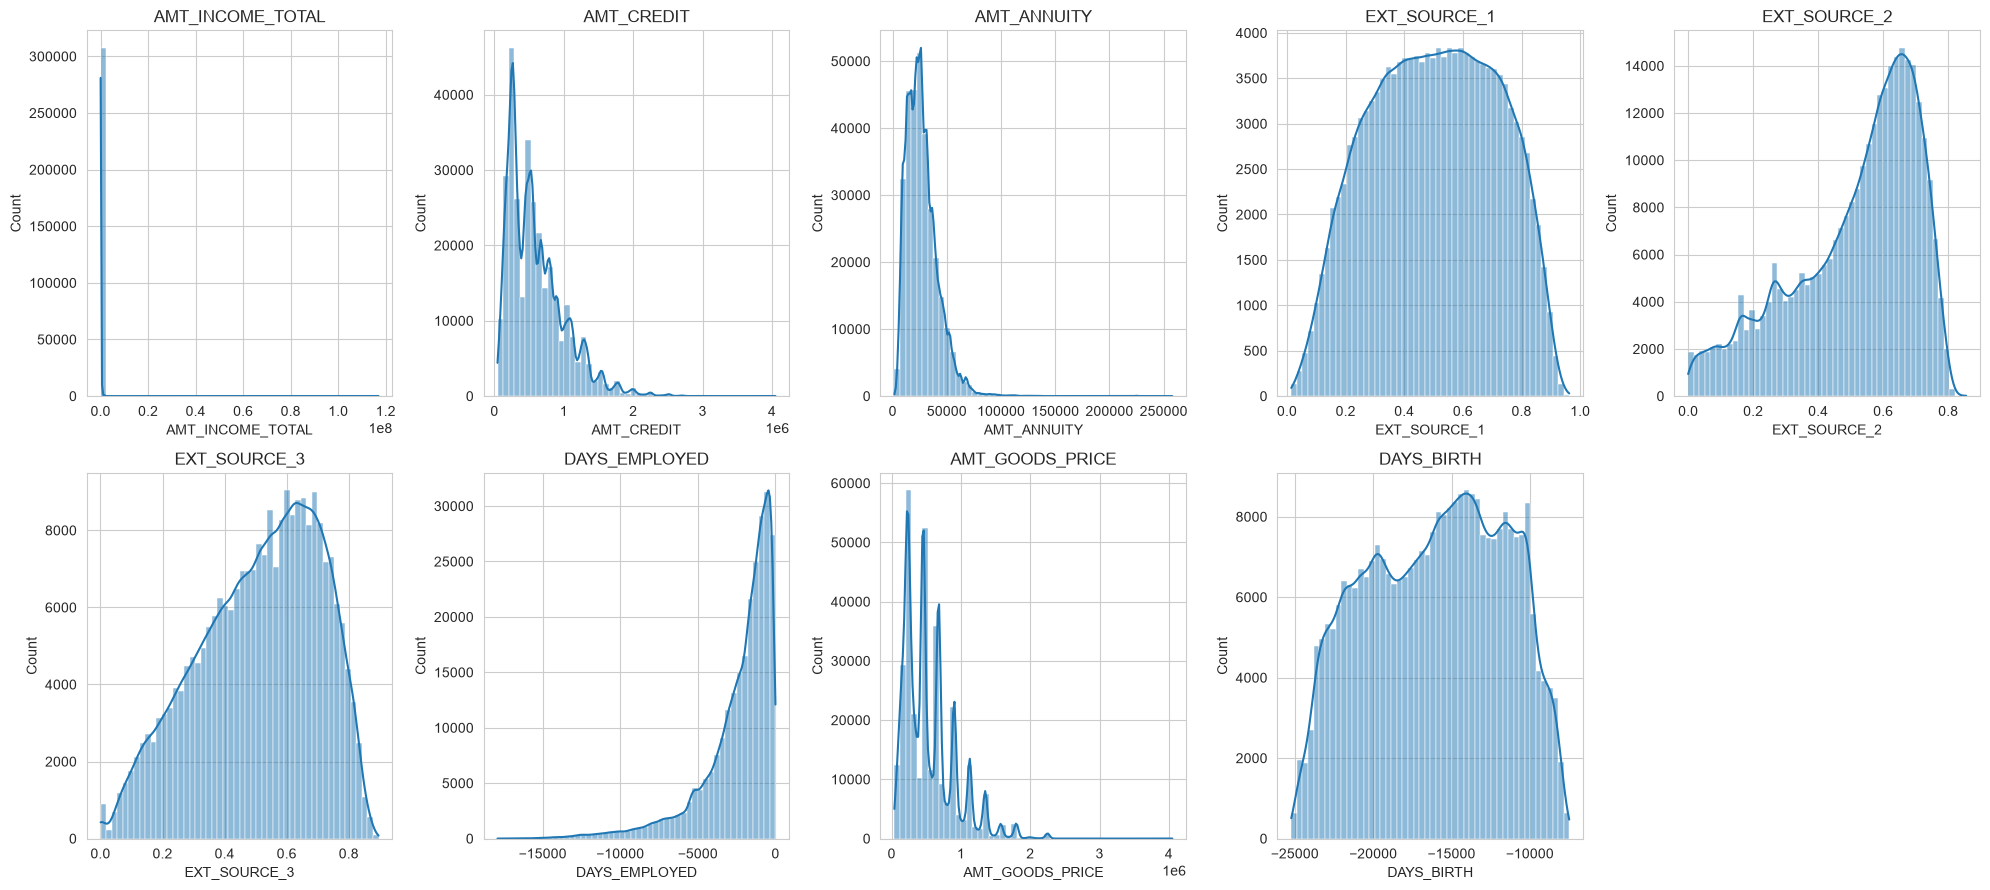

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_key_cols):
    data_to_plot = df[col].dropna()
    if col == "DAYS_EMPLOYED":
        data_to_plot = data_to_plot[data_to_plot != 365243]
    sns.histplot(data_to_plot, kde=True, ax=axes[i], bins=50)
    axes[i].set_title(col) 
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../reports/figures/05_numeric_distributions.png", dpi=150)
plt.show()

# 6.a Pengechekan Kolom Days untuk tau rentang min max ketika anomali tidak ada

In [23]:
age_years = -df["DAYS_BIRTH"] / 365
employment_years = -df.loc[df["DAYS_EMPLOYED"] != 365243, "DAYS_EMPLOYED"] / 365

print(f"Rentang umur (tahun): {age_years.min():.1f} - {age_years.max():.1f}")
print(f"Rentang masa kerja (tahun, exclude anomaly 365243): {employment_years.min():.1f} - {employment_years.max():.1f}")

invalid_age = ((age_years < 18) | (age_years > 100)).sum()
print(f"\nJumlah baris dengan umur tidak masuk akal (<18 atau >100 tahun): {invalid_age}")

Rentang umur (tahun): 20.5 - 69.1
Rentang masa kerja (tahun, exclude anomaly 365243): 0.0 - 49.1

Jumlah baris dengan umur tidak masuk akal (<18 atau >100 tahun): 0


# 6.a Nilai negatif wajar karena

In [24]:
positive_days_cols = ["DAYS_BIRTH", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE"]

for col in positive_days_cols:
    n_positive = (df[col] > 0).sum()
    print(f"{col}: {n_positive} baris bernilai positif (seharusnya negatif/0 — hari sebelum tanggal aplikasi)")

DAYS_BIRTH: 0 baris bernilai positif (seharusnya negatif/0 — hari sebelum tanggal aplikasi)
DAYS_REGISTRATION: 0 baris bernilai positif (seharusnya negatif/0 — hari sebelum tanggal aplikasi)
DAYS_ID_PUBLISH: 0 baris bernilai positif (seharusnya negatif/0 — hari sebelum tanggal aplikasi)
DAYS_LAST_PHONE_CHANGE: 0 baris bernilai positif (seharusnya negatif/0 — hari sebelum tanggal aplikasi)


# 6.b Cross-Check Anomali DAYS_EMPLOYED 

In [25]:
anomaly_mask = df["DAYS_EMPLOYED"] == 365243

income_type_crosstab = pd.crosstab(anomaly_mask, df["NAME_INCOME_TYPE"], normalize="index") * 100
print("Distribusi NAME_INCOME_TYPE — baris anomaly vs normal (%):")
print(income_type_crosstab.round(2).T)

pct_anomaly_is_pensioner = (df.loc[anomaly_mask, "NAME_INCOME_TYPE"] == "Pensioner").mean() * 100
print(f"\n{pct_anomaly_is_pensioner:.2f}% dari baris anomaly adalah NAME_INCOME_TYPE = 'Pensioner'")

non_pensioner_anomaly = df.loc[anomaly_mask & (df["NAME_INCOME_TYPE"] != "Pensioner")]
print(f"Jumlah baris anomaly yang BUKAN Pensioner: {len(non_pensioner_anomaly)}")
if len(non_pensioner_anomaly) > 0:
    print("\nDistribusi kategori non-Pensioner yang tetap anomaly:")
    print(non_pensioner_anomaly["NAME_INCOME_TYPE"].value_counts())

Distribusi NAME_INCOME_TYPE — baris anomaly vs normal (%):
DAYS_EMPLOYED         False  True 
NAME_INCOME_TYPE                  
Businessman            0.00   0.00
Commercial associate  28.40   0.00
Maternity leave        0.00   0.00
Pensioner              0.00  99.96
State servant          8.61   0.00
Student                0.01   0.00
Unemployed             0.00   0.04
Working               62.97   0.00

99.96% dari baris anomaly adalah NAME_INCOME_TYPE = 'Pensioner'
Jumlah baris anomaly yang BUKAN Pensioner: 22

Distribusi kategori non-Pensioner yang tetap anomaly:
NAME_INCOME_TYPE
Unemployed    22
Name: count, dtype: int64


In [26]:
if len(non_pensioner_anomaly) == 0:
    print("KESIMPULAN: anomaly 365243 sepenuhnya berasal dari klien Pensioner.")
    print("-> Bukan error data, tapi representasi valid 'tidak bekerja'.")
    print("-> Strategi cleaning: replace 365243 -> NaN. Kategori 'Pensioner' di")
    print("   NAME_INCOME_TYPE sudah cukup sebagai flag, tidak perlu kolom flag tambahan.")
else:
    pct_non_pensioner = len(non_pensioner_anomaly) / anomaly_mask.sum() * 100
    print(f"KESIMPULAN: {pct_non_pensioner:.2f}% anomaly BUKAN dari Pensioner.")
    print("-> Perlu ditelusuri lebih lanjut, kemungkinan ada data entry error di luar")
    print("   kategori pensiunan. Strategi cleaning: replace 365243 -> NaN + buat")
    print("   kolom flag 'DAYS_EMPLOYED_ANOMALY' terpisah dari NAME_INCOME_TYPE.")

KESIMPULAN: 0.04% anomaly BUKAN dari Pensioner.
-> Perlu ditelusuri lebih lanjut, kemungkinan ada data entry error di luar
   kategori pensiunan. Strategi cleaning: replace 365243 -> NaN + buat
   kolom flag 'DAYS_EMPLOYED_ANOMALY' terpisah dari NAME_INCOME_TYPE.


# Keputusan Outlier

In [27]:
from scipy.stats import skew

financial_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]

outlier_decision = []
for col in financial_cols:
    col_skew = skew(df[col].dropna())
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    pct_outlier = (df[col] > upper_bound).mean() * 100

    if abs(col_skew) > 1 and pct_outlier > 1:
        decision = "Log-transform (skewed kuat + outlier signifikan)"
    elif pct_outlier > 5:
        decision = "Cap di persentil 99 (outlier > 5%)"
    else:
        decision = "Biarkan (tree-based model relatif tahan outlier)"

    outlier_decision.append({
        "feature": col,
        "skewness": round(col_skew, 2),
        "pct_outlier_iqr": round(pct_outlier, 2),
        "decision": decision
    })

outlier_decision_df = pd.DataFrame(outlier_decision)
print(outlier_decision_df.to_string(index=False))

         feature  skewness  pct_outlier_iqr                                         decision
AMT_INCOME_TOTAL    391.56             4.56 Log-transform (skewed kuat + outlier signifikan)
      AMT_CREDIT      1.23             2.13 Log-transform (skewed kuat + outlier signifikan)
     AMT_ANNUITY      1.58             2.44 Log-transform (skewed kuat + outlier signifikan)
 AMT_GOODS_PRICE      1.35             4.79 Log-transform (skewed kuat + outlier signifikan)


In [28]:
os.makedirs("../data/processed", exist_ok=True)
outlier_decision_df.to_csv("../data/processed/outlier_treatment_decision.csv", index=False)
print("Tersimpan: ../data/processed/outlier_treatment_decision.csv")
print("\nCatatan: jika model utama tree-based (LightGBM/XGBoost), kolom 'Biarkan' tidak")
print("perlu ditransform. Jika ada baseline linear/KNN, semua kolom finansial tetap perlu")
print("di-scale terlepas dari keputusan capping/transform di atas.")

Tersimpan: ../data/processed/outlier_treatment_decision.csv

Catatan: jika model utama tree-based (LightGBM/XGBoost), kolom 'Biarkan' tidak
perlu ditransform. Jika ada baseline linear/KNN, semua kolom finansial tetap perlu
di-scale terlepas dari keputusan capping/transform di atas.


# 6.c Kolom penting yang di ambil dari Kategorikal


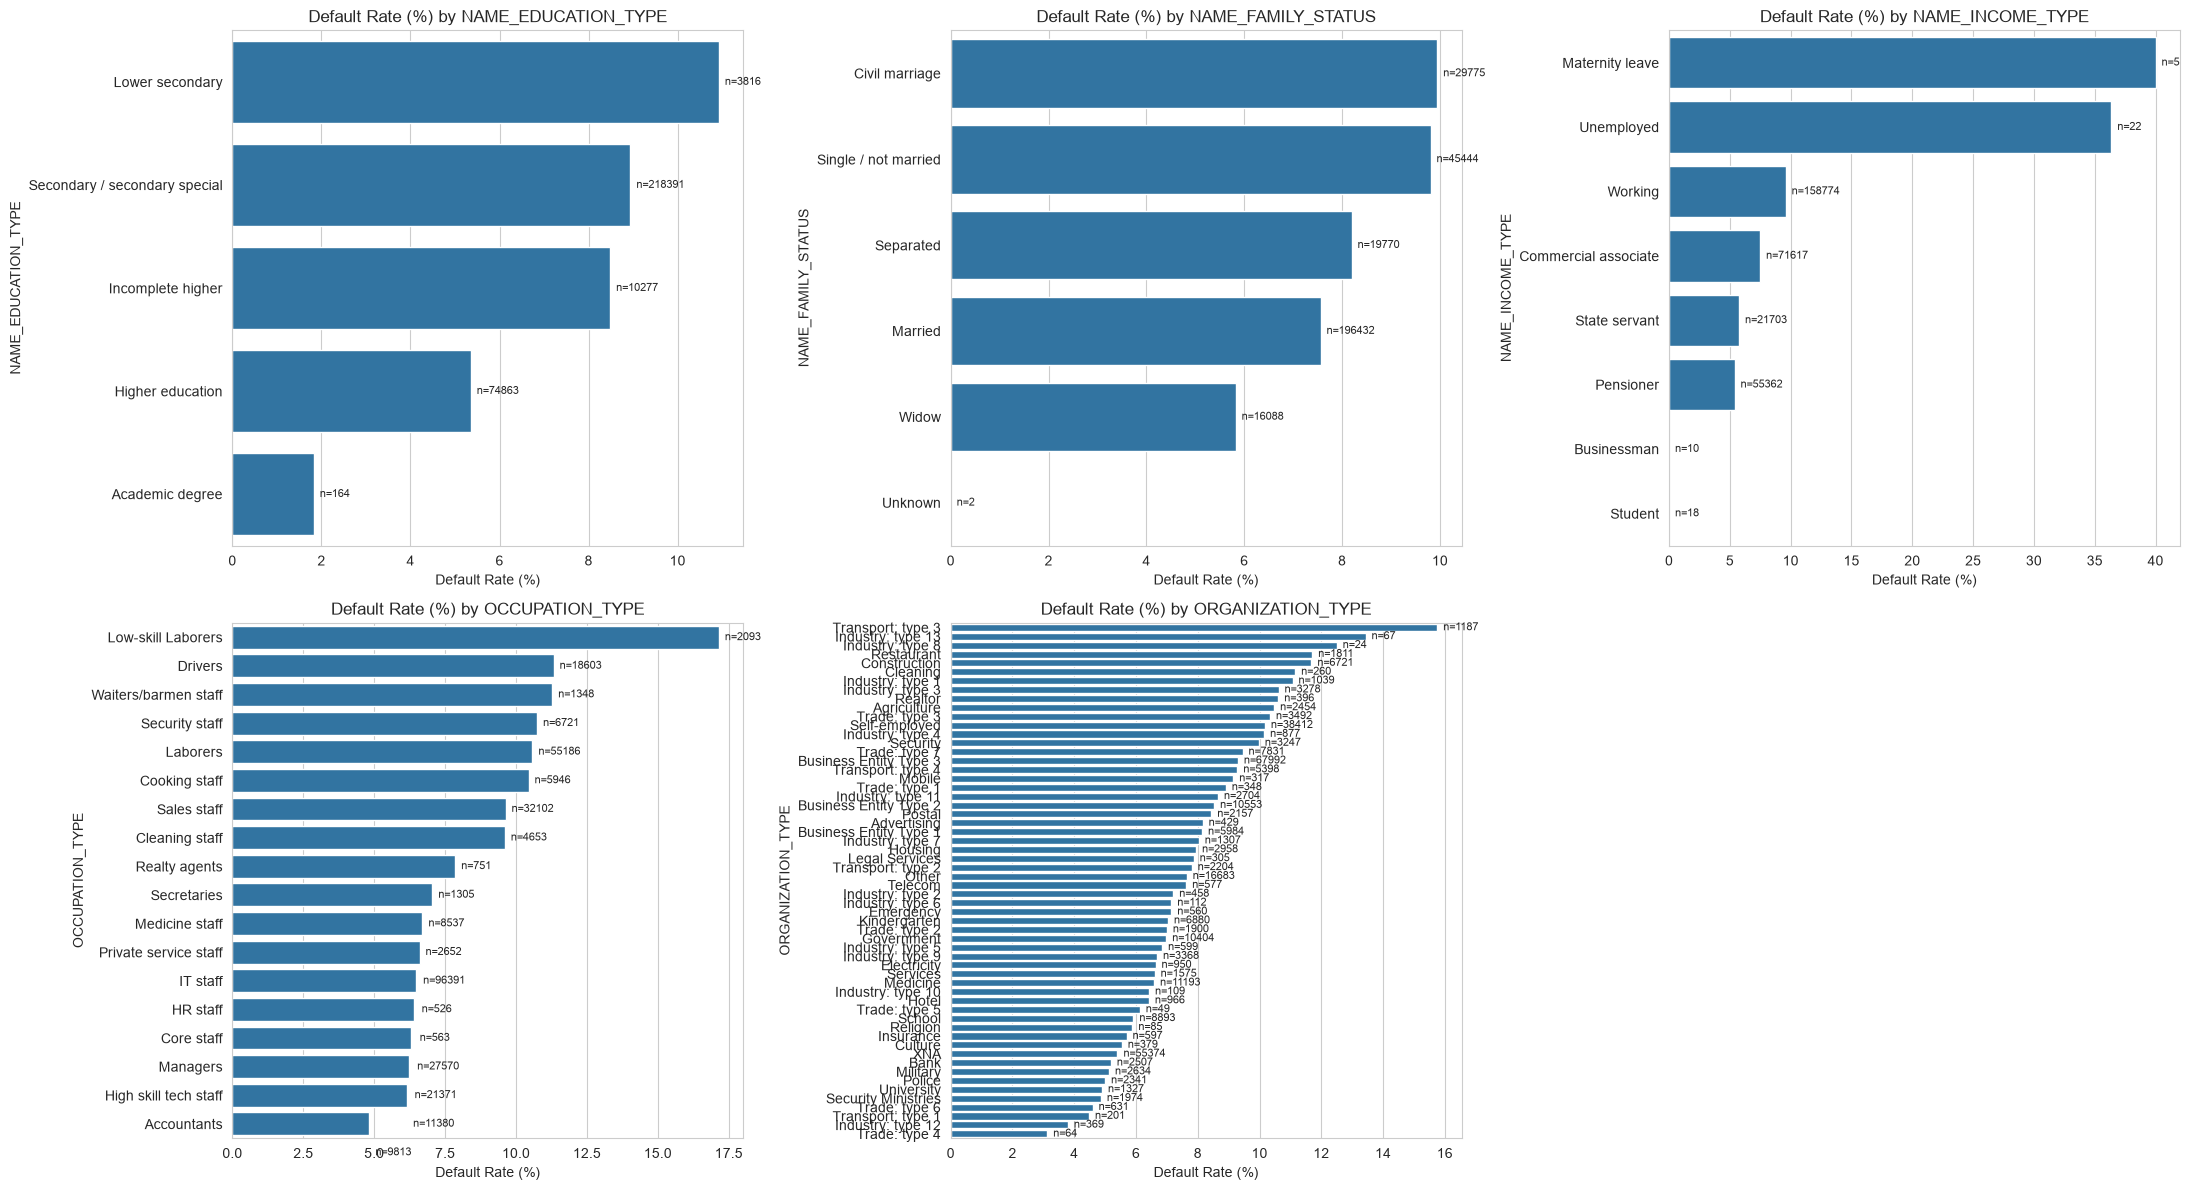

In [29]:
# --- KATEGORIKAL ---
categorical_key_cols = ["NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_INCOME_TYPE",
                         "OCCUPATION_TYPE", "ORGANIZATION_TYPE"]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))  # 6 slot untuk 5 kolom
axes = axes.flatten()

for i, col in enumerate(categorical_key_cols):
    grouped = df.groupby(col, dropna=False)["TARGET"].agg(["mean", "count"])
    grouped["mean"] *= 100
    grouped = grouped.sort_values("mean", ascending=False)

    sns.barplot(x=grouped["mean"], y=grouped.index.astype(str), ax=axes[i])
    axes[i].set_title(f"Default Rate (%) by {col}")
    axes[i].set_xlabel("Default Rate (%)")
    for j, (rate, n) in enumerate(zip(grouped["mean"], grouped["count"])):
        axes[i].text(rate, j, f"  n={n}", va="center", fontsize=8)

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../reports/figures/06_categorical_vs_target.png", dpi=150)
plt.show()

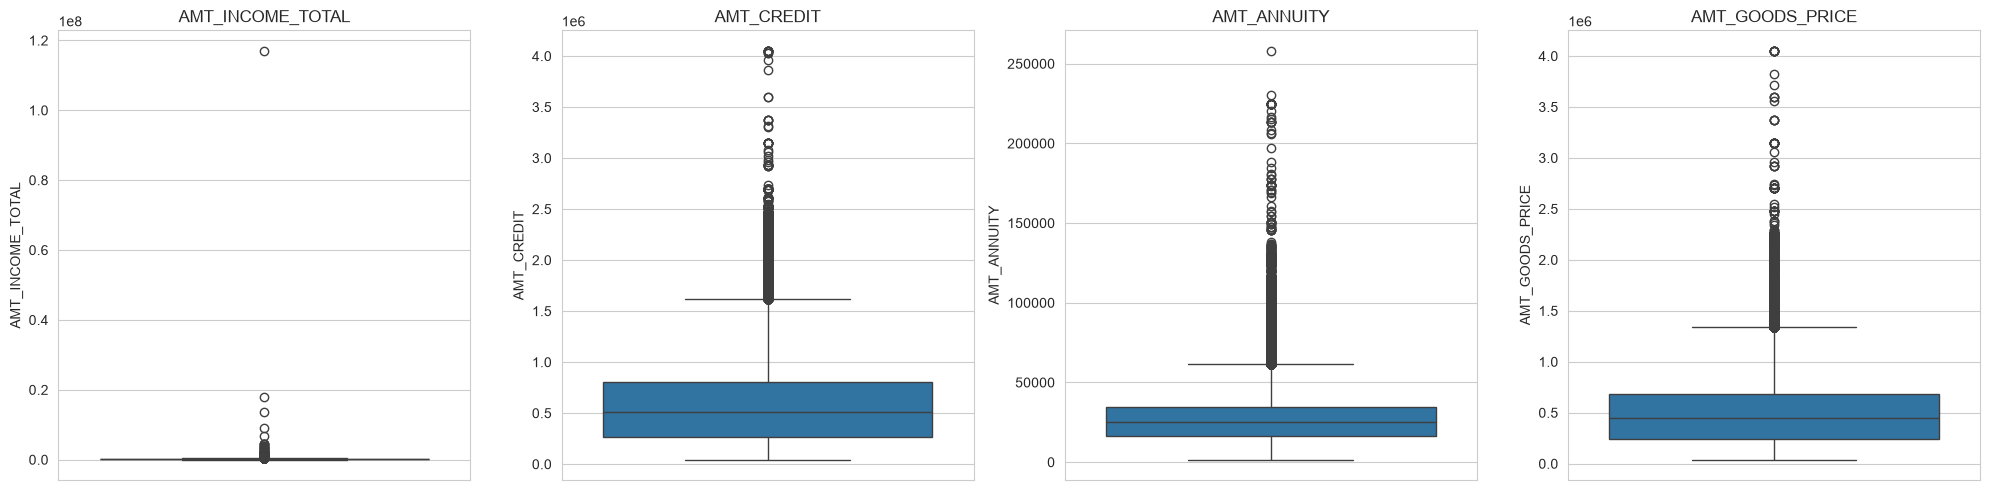

AMT_INCOME_TOTAL: 14035 outlier (4.56%), batas atas IQR = 337,500
AMT_CREDIT: 6562 outlier (2.13%), batas atas IQR = 1,616,625
AMT_ANNUITY: 7504 outlier (2.44%), batas atas IQR = 61,704
AMT_GOODS_PRICE: 14728 outlier (4.79%), batas atas IQR = 1,341,000


In [30]:
financial_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(financial_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig("../reports/figures/07_outlier_boxplots.png", dpi=150)
plt.show()

for col in financial_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    n_outliers = (df[col] > upper_bound).sum()
    print(f"{col}: {n_outliers} outlier ({n_outliers/len(df)*100:.2f}%), batas atas IQR = {upper_bound:,.0f}")

In [31]:
categorical_all = df.select_dtypes(include="object").columns
cardinality = df[categorical_all].nunique().sort_values(ascending=False)
print("Cardinality tiap fitur kategorikal:")
print(cardinality)

Cardinality tiap fitur kategorikal:
ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FLAG_OWN_CAR                   2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_21740\1177552335.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_all = df.select_dtypes(include="object").columns


# 6.d Cross-Check Bagian 6.c dengan Daftar Terpilih

In [32]:
key_categorical_cols = ["NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_INCOME_TYPE",
                          "OCCUPATION_TYPE", "ORGANIZATION_TYPE"]
selected_features_list = selected_df["feature"].tolist()

crosscheck = pd.DataFrame({
    "feature": key_categorical_cols,
    "in_selected_features_eda": [c in selected_features_list for c in key_categorical_cols]
})
print(crosscheck)

not_selected = crosscheck[~crosscheck["in_selected_features_eda"]]
if len(not_selected) > 0:
    print("\nPERHATIAN: fitur berikut disorot di 6.b tapi TIDAK lolos kriteria Bagian 5:")
    print(not_selected["feature"].tolist())
else:
    print("\nSemua fitur di 6.b sudah konsisten dengan hasil seleksi otomatis Bagian 5.")

               feature  in_selected_features_eda
0  NAME_EDUCATION_TYPE                      True
1   NAME_FAMILY_STATUS                      True
2     NAME_INCOME_TYPE                      True
3      OCCUPATION_TYPE                      True
4    ORGANIZATION_TYPE                      True

Semua fitur di 6.b sudah konsisten dengan hasil seleksi otomatis Bagian 5.


In [33]:
missing_business_features = not_selected["feature"].tolist() if len(not_selected) > 0 else []

if missing_business_features:
    override_rows = []
    for col in missing_business_features:
        override_rows.append({
            "feature": col,
            "information_value": iv_df_all.loc[col, "information_value"] if col in iv_df_all.index else np.nan,
            "missing_pct": missing_pct.get(col, np.nan),
            "dtype": iv_df_all.loc[col, "dtype"] if col in iv_df_all.index else "categorical",
            "iv_category": iv_df_all.loc[col, "category"] if col in iv_df_all.index else np.nan,
            "reason": "Manual_override_business_insight",
            "is_near_zero_variance": False
        })
    override_df = pd.DataFrame(override_rows)
    selected_df = pd.concat([selected_df, override_df], ignore_index=True)
    selected_df.to_csv("../data/processed/selected_features_eda.csv", index=False)
    print(f"Ditambahkan {len(override_df)} fitur manual override ke selected_features_eda.csv")
else:
    print("Tidak ada penambahan manual diperlukan — daftar sudah final.")

Tidak ada penambahan manual diperlukan — daftar sudah final.


C:\Users\USER\AppData\Local\Temp\ipykernel_21740\96099129.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365).astype(int)


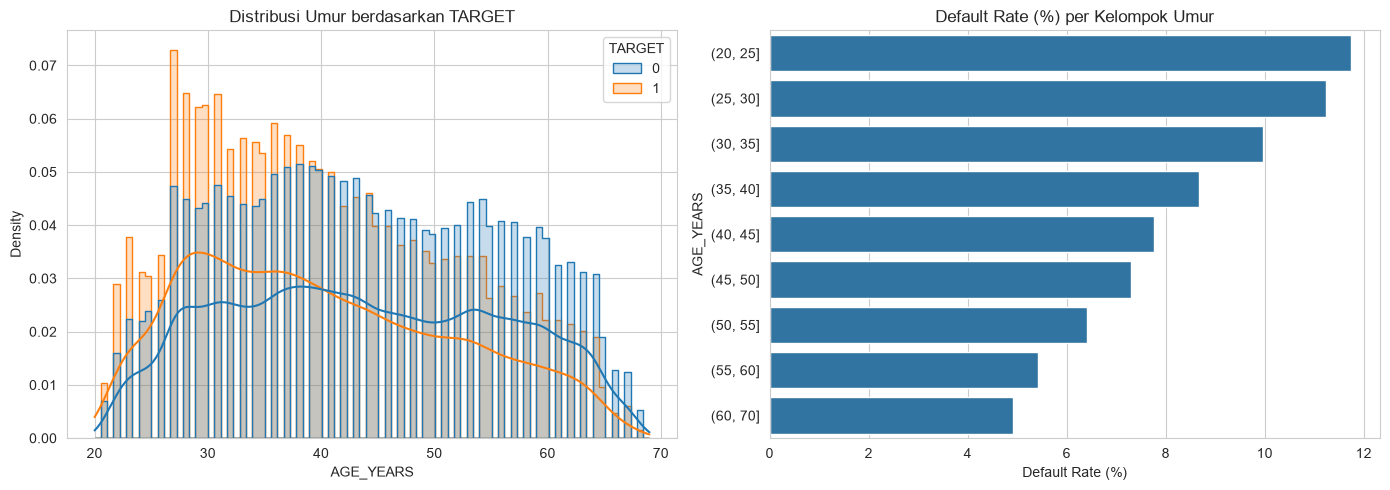

In [34]:
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x="AGE_YEARS", hue="TARGET", kde=True, ax=axes[0],
             element="step", stat="density", common_norm=False)
axes[0].set_title("Distribusi Umur berdasarkan TARGET")

age_bins = pd.cut(df["AGE_YEARS"], bins=[20, 25, 30, 35, 40, 45, 50, 55, 60, 70])
age_default_rate = df.groupby(age_bins, observed=True)["TARGET"].mean() * 100
sns.barplot(x=age_default_rate.values, y=age_default_rate.index.astype(str), ax=axes[1])
axes[1].set_title("Default Rate (%) per Kelompok Umur")
axes[1].set_xlabel("Default Rate (%)")
plt.tight_layout()
plt.savefig("../reports/figures/08_age_vs_target.png", dpi=150)
plt.show()

# 7. Kesimpulan & Langkah Selanjutnya
Ringkasan hasil dan tujuan sebagai penutup notebook, jadi rujukan untuk tahap berikutnya.

In [35]:
print("=" * 75)
print("RINGKASAN EDA — HOME CREDIT DEFAULT RISK")
print("=" * 75)

print("\n[DATA QUALITY]")
print(f"Total baris                : {df.shape[0]:,}")
print(f"Total fitur awal            : {len(feature_cols)}")
print(f"Baris duplikat              : {n_duplicate_rows}")
print(f"Umur tidak masuk akal       : {invalid_age} baris")
print(f"Imbalance TARGET            : {target_pct.round(2).to_dict()}")

print("\n[MISSING VALUE]")
print(f"Kolom missing (isnull)      : {(missing_df['missing_count'] > 0).sum()} dari {len(feature_cols)} fitur")
print(f"Hidden missing ditemukan    : {len(hidden_missing_df)} kombinasi kolom-placeholder")
if len(hidden_missing_df) > 0:
    print(f"  -> Kolom terdampak: {hidden_missing_df['feature'].unique().tolist()}")
print(f"Pasangan kolom missing mirip (corr>0.8): {len(high_corr_df)} pasangan")
print(f"  -> Rata-rata korelasi missing grup housing: {avg_corr_within_group:.3f}")
print("  -> Kesimpulan: missing pada grup housing bersifat TERSTRUKTUR (bukan acak)")

print("\n[SELEKSI FITUR]")
print(f"Fitur kandidat FE (IV Top10 OR Missing<51%): {len(selected_df)}")
print(f"Fitur dibuang               : {len(excluded_features)}")
print(f"Fitur near-zero variance    : {selected_df['is_near_zero_variance'].sum()} dari {len(selected_df)} kandidat")

print("\n[ANOMALI]")
print(f"DAYS_EMPLOYED == 365243     : {anomaly_count} baris ({anomaly_count/len(df)*100:.2f}%)")
print(f"  -> {100 - len(non_pensioner_anomaly)/anomaly_count*100:.2f}% dari anomali adalah Pensioner (representasi valid)")
print(f"  -> {len(non_pensioner_anomaly)} baris anomali BUKAN Pensioner (perlu flag terpisah)")

print("\n[OUTLIER]")
for _, row in outlier_decision_df.iterrows():
    print(f"  {row['feature']:20s} -> {row['decision']}")

print("\n[VALIDASI 6.c/6.d]")
if len(not_selected) > 0:
    print(f"PERHATIAN: {len(not_selected)} fitur bisnis penting tidak lolos seleksi otomatis:")
    print(f"  {not_selected['feature'].tolist()}")
else:
    print("Semua fitur kategorikal penting sudah konsisten dengan hasil seleksi Bagian 5.")

print("\n" + "=" * 75)
print("NEXT STEPS")
print("=" * 75)
print("02_Cleaning.ipynb:")
print(f"  1. Replace DAYS_EMPLOYED==365243 -> NaN.")
if len(non_pensioner_anomaly) > 0:
    print(f"     Buat flag 'DAYS_EMPLOYED_ANOMALY' karena {len(non_pensioner_anomaly)} baris non-Pensioner tetap anomaly.")
else:
    print("     Tidak perlu flag tambahan, seluruh anomaly adalah Pensioner.")
print(f"  2. Replace placeholder ('XNA', dll) di {hidden_missing_df['feature'].nunique() if len(hidden_missing_df)>0 else 0} kolom kategorikal -> NaN.")
print("  3. Imputasi grup untuk kolom housing (missing terstruktur) — gunakan flag")
print("     'HAS_HOUSING_INFO' + imputasi median, bukan imputasi per-kolom independen.")
print("  4. Terapkan keputusan outlier di atas pada kolom finansial.")
print()
print("03_feature_engineering.ipynb:")
print(f"  1. Load 'selected_features_eda.csv' ({len(selected_df)} kandidat fitur).")
print("  2. Cek redundansi: Pearson & Spearman untuk numerik, Cramer's V untuk kategorikal.")
print(f"  3. Evaluasi ulang {selected_df['is_near_zero_variance'].sum()} fitur near-zero-variance")
print("     via VarianceThreshold — pertahankan hanya jika IV tinggi.")
print("  4. Hasilkan daftar fitur final untuk modeling.")

RINGKASAN EDA — HOME CREDIT DEFAULT RISK

[DATA QUALITY]
Total baris                : 307,511
Total fitur awal            : 120
Baris duplikat              : 0
Umur tidak masuk akal       : 0 baris
Imbalance TARGET            : {0: 91.93, 1: 8.07}

[MISSING VALUE]
Kolom missing (isnull)      : 67 dari 120 fitur
Hidden missing ditemukan    : 4 kombinasi kolom-placeholder
  -> Kolom terdampak: ['ORGANIZATION_TYPE', 'NAME_FAMILY_STATUS', 'CODE_GENDER']
Pasangan kolom missing mirip (corr>0.8): 597 pasangan
  -> Rata-rata korelasi missing grup housing: 0.815
  -> Kesimpulan: missing pada grup housing bersifat TERSTRUKTUR (bukan acak)

[SELEKSI FITUR]
Fitur kandidat FE (IV Top10 OR Missing<51%): 91
Fitur dibuang               : 29
Fitur near-zero variance    : 18 dari 91 kandidat

[ANOMALI]
DAYS_EMPLOYED == 365243     : 55374 baris (18.01%)
  -> 99.96% dari anomali adalah Pensioner (representasi valid)
  -> 22 baris anomali BUKAN Pensioner (perlu flag terpisah)

[OUTLIER]
  AMT_INCOME_TOTAL 